# 03. scVI — Unsupervised Deep Learning Integration

**Why this is not just "Harmony but fancier"**: Harmony corrects coordinates after PCA
has already been computed. scVI is a variational autoencoder — a network that learns to
compress each cell into a latent vector while explicitly modeling batch as part of the
generative process, so the batch-specific variation gets absorbed into a parameter the
model is allowed to ignore rather than baked into the coordinates it outputs. It models
counts with a negative binomial distribution, which is the standard choice for
overdispersed sequencing noise.

One practical point: scVI wants counts (`layer="counts"`), not the scaled values used for
Harmony. It does its own normalization internally during training.


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scvi
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sc.settings.verbosity = 1
print(f"scanpy: {sc.__version__}")
print(f"scvi-tools: {scvi.__version__}")

scanpy: 1.12.2
scvi-tools: 1.5.0.post1


## 1. Loading the data and selecting the same 2000 HVGs

We use the full object from `01_qc_eda.ipynb` (not the Harmony version with scaling
already applied — scVI needs "raw" counts, not scaled values).

In [2]:
adata = sc.read("../data/processed/pancreas_prepared.h5ad")

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="tech", subset=False)
adata_scvi = adata[:, adata.var["highly_variable"]].copy()
print(adata_scvi)

AnnData object with n_obs × n_vars = 16382 × 2000
    obs: 'tech', 'celltype', 'size_factors'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg'
    layers: 'counts', None (.X)


## 2. Checking the counts layer

Recall the caveat from notebook 01: the `counts` layer here is not raw integer UMI counts,
but values reconstructed from scran size factors (fractional numbers). scVI expects
count-like data for the negative binomial likelihood; let's check the range and round if
needed — a compromise that should be stated explicitly in the report, not hidden.

In [3]:
counts = adata_scvi.layers["counts"]
counts_dense_sample = counts[:5, :5].toarray() if hasattr(counts, "toarray") else counts[:5, :5]
print("Sample values in the counts layer:\n", counts_dense_sample)
print("Min:", counts.min(), "Max:", counts.max())
print("Any negative values:", (counts.min() < 0))

# scVI expects count-like (non-negative, roughly integer) data.
# Round to integers, keeping the original layer untouched under a different name just in case.
adata_scvi.layers["counts_raw"] = adata_scvi.layers["counts"].copy()
adata_scvi.layers["counts"] = np.round(adata_scvi.layers["counts"].toarray() if hasattr(adata_scvi.layers["counts"], "toarray") else adata_scvi.layers["counts"])
print("After rounding, max:", adata_scvi.layers["counts"].max())

Sample values in the counts layer:
 [[0.        0.        0.        0.        4.0315795]
 [0.        0.        0.        0.        1.0019583]
 [0.        0.        0.        0.        1.0019583]
 [0.        0.        1.0019583 0.        2.0078535]
 [0.        0.        0.        0.        0.       ]]
Min: 0.0 Max: 1.453667e+06
Any negative values: False
After rounding, max: 1.453667e+06


## 3. Setting up and training scVI

`setup_anndata` registers where the counts live and where the batch label is. `n_latent=30`
— the same latent dimensionality as PCA in Harmony (for a fair comparison).

On CPU, for 16,382 cells and 2000 genes, training typically takes **5-15 minutes** for a
reasonable number of epochs — a GPU is not required.

Seed set to 0


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


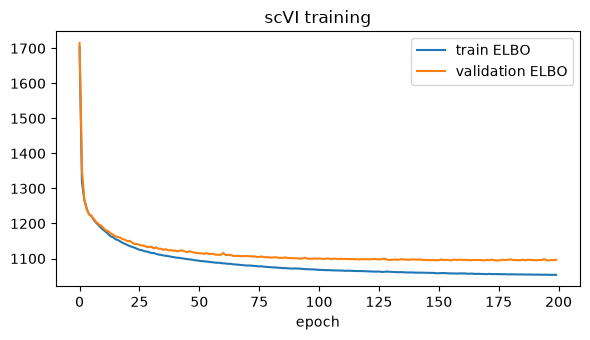

In [4]:
scvi.settings.seed = 0          # fixed seed; run-to-run spread is measured in notebook 07

scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key="tech")

model = scvi.model.SCVI(adata_scvi, n_latent=30, n_layers=2)
model.train(max_epochs=200, early_stopping=True)

# training curves — "max_epochs=200 reached" says nothing about convergence, this does
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(model.history["elbo_train"], label="train ELBO")
ax.plot(model.history["elbo_validation"], label="validation ELBO")
ax.set_xlabel("epoch"); ax.legend(); ax.set_title("scVI training")
plt.tight_layout(); plt.savefig("../results/figures/03_training_curve.png", dpi=150); plt.show()

## 4. Extracting the latent representation and UMAP

`get_latent_representation()` is exactly the VAE encoder's output: a 30-dimensional
vector per cell, with batch-specific variation removed.

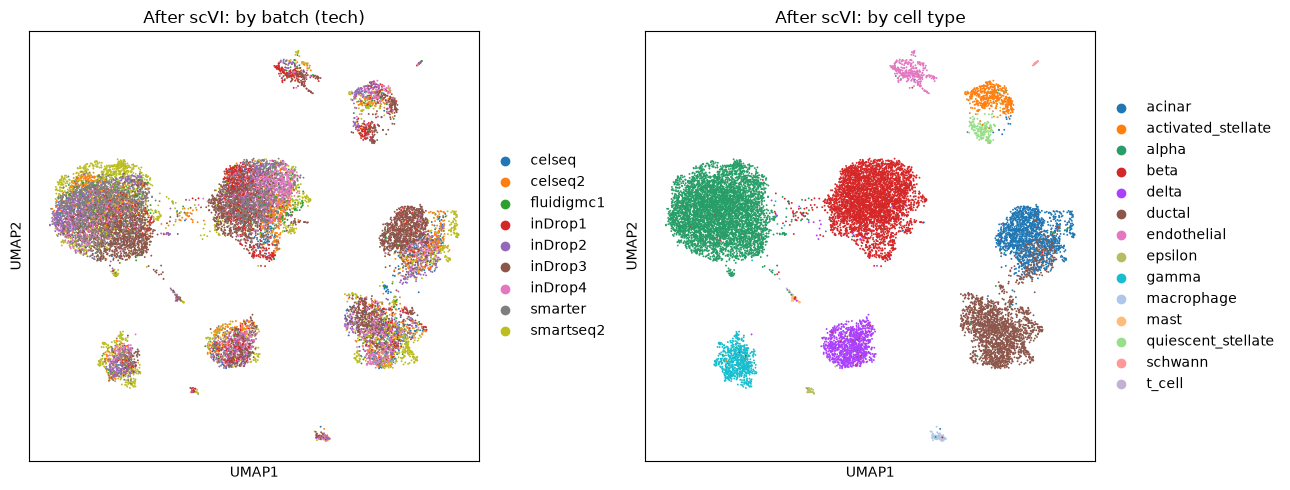

In [5]:
adata_scvi.obsm["X_scVI"] = model.get_latent_representation()

sc.pp.neighbors(adata_scvi, use_rep="X_scVI")
sc.tl.umap(adata_scvi)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata_scvi, color="tech", ax=axes[0], show=False, title="After scVI: by batch (tech)")
sc.pl.umap(adata_scvi, color="celltype", ax=axes[1], show=False, title="After scVI: by cell type")
plt.tight_layout()
plt.savefig("../results/figures/03_scvi_umap.png", dpi=150)
plt.show()

**What to compare with the Harmony picture (notebook 02):** did batches mix as well
within clusters? Are cell types still as clearly separated, or did scVI "overdo it" and
mix different types together?

## 5. Resolution sweep — same approach as for Harmony

Using the same resolution grid as in notebook 02, for a fair "apples to apples"
comparison.

In [6]:
resolutions = [0.3, 0.5, 0.7, 1.0, 1.3]
sweep_results = []

for res in resolutions:
    sc.tl.leiden(
        adata_scvi, resolution=res, flavor="igraph", n_iterations=2,
        directed=False, key_added=f"leiden_r{res}",
    )
    ari = adjusted_rand_score(adata_scvi.obs["celltype"], adata_scvi.obs[f"leiden_r{res}"])
    nmi = normalized_mutual_info_score(adata_scvi.obs["celltype"], adata_scvi.obs[f"leiden_r{res}"])
    n_clusters = adata_scvi.obs[f"leiden_r{res}"].nunique()
    sweep_results.append({"resolution": res, "ARI": ari, "NMI": nmi, "n_clusters": n_clusters})

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,resolution,ARI,NMI,n_clusters
0,0.3,0.952699,0.921997,11
1,0.5,0.942477,0.910338,13
2,0.7,0.743858,0.837622,16
3,1.0,0.635168,0.794361,21
4,1.3,0.445060,0.728686,27


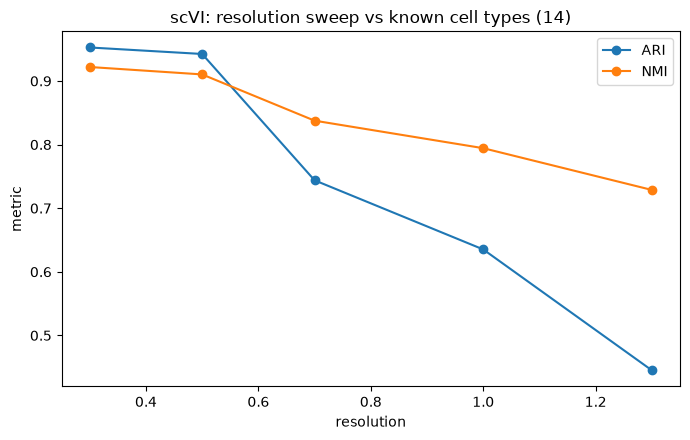

Best resolution: 0.3
ARI (scVI vs celltype): 0.953
NMI (scVI vs celltype): 0.922
Number of Leiden clusters: 11, known cell types: 14


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_df["resolution"], sweep_df["ARI"], marker="o", label="ARI")
ax.plot(sweep_df["resolution"], sweep_df["NMI"], marker="o", label="NMI")
ax.set_xlabel("resolution")
ax.set_ylabel("metric")
ax.set_title("scVI: resolution sweep vs known cell types (14)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/03_resolution_sweep.png", dpi=150)
plt.show()

best_res = sweep_df.loc[sweep_df["ARI"].idxmax(), "resolution"]
adata_scvi.obs["leiden"] = adata_scvi.obs[f"leiden_r{best_res}"]
ari = sweep_df.loc[sweep_df["ARI"].idxmax(), "ARI"]
nmi = sweep_df.loc[sweep_df["ARI"].idxmax(), "NMI"]
print(f"Best resolution: {best_res}")
print(f"ARI (scVI vs celltype): {ari:.3f}")
print(f"NMI (scVI vs celltype): {nmi:.3f}")
print(f"Number of Leiden clusters: {adata_scvi.obs['leiden'].nunique()}, known cell types: {adata_scvi.obs['celltype'].nunique()}")

## 6. Saving the result

In [8]:
adata_scvi.write("../data/processed/pancreas_scvi.h5ad")
print("Saved:", adata_scvi.shape)

Saved: (16382, 2000)


## Conclusions

scVI (seed 0): ARI = 0.953, NMI = 0.922 at resolution 0.3 (11 clusters). A bit better
than Harmony (0.914 / 0.888) on both metrics, though "a bit" is doing real work in that
sentence — this is not a large gain. The training curve flattens well before epoch 200;
early stopping never fired, but the model is not under-trained.

Seed fixed at 0 from this version on. The spread across five seeds (mean ± sd for
ARI/NMI, held-out accuracy and macro-F1, training curves) is in `07_seed_stability.ipynb`;
single-run numbers in this notebook are one draw from that distribution. This draw is a
lucky one: the five-seed mean in 07 is 0.946 ± 0.002, so 0.953 sits about three standard
deviations above it. A fixed seed makes *this notebook* reproducible; it does not make one
number the result.

Next: scANVI, which gets to see some of the labels — `04_scanvi.ipynb`.